### kNN

Точность модели: 0.9714

Отчет по классификации:
               precision    recall  f1-score   support

           0     0.9731    0.9964    0.9846      1381
           1     0.9572    0.9943    0.9754      1575
           2     0.9882    0.9621    0.9750      1398
           3     0.9707    0.9734    0.9720      1428
           4     0.9790    0.9575    0.9681      1365
           5     0.9666    0.9612    0.9639      1263
           6     0.9755    0.9840    0.9797      1375
           7     0.9654    0.9753    0.9703      1459
           8     0.9884    0.9399    0.9636      1365
           9     0.9545    0.9655    0.9600      1391

    accuracy                         0.9714     14000
   macro avg     0.9719    0.9710    0.9713     14000
weighted avg     0.9716    0.9714    0.9714     14000



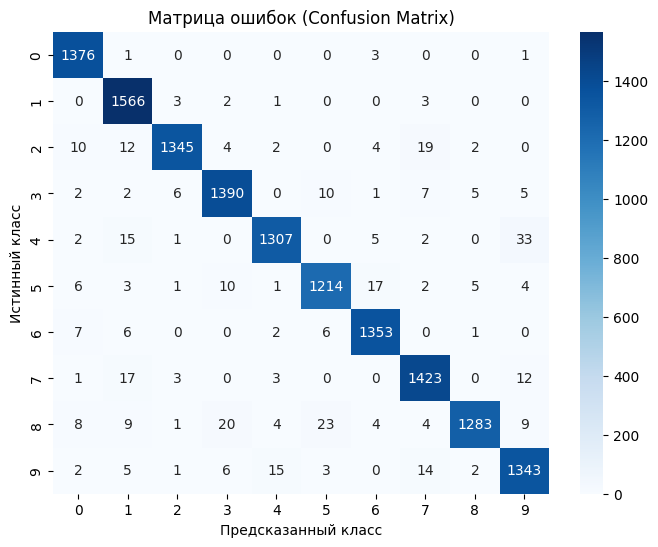

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import fetch_openml
import seaborn as sns

#датасет MNIST
mnist = fetch_openml('mnist_784', version=1, cache=True, parser="auto")
X, y = mnist.data, mnist.target.astype(int)  

#нормализация пикселей 
X = X / 255.0

#80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#kNN 
classifier = KNeighborsClassifier(n_neighbors=3)  


classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, digits=4)
conf_matrix = confusion_matrix(y_test, y_pred)


print(f"Точность модели: {accuracy:.4f}")
print("\nОтчет по классификации:\n", report)


plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.title("Матрица ошибок (Confusion Matrix)")
plt.show()




Общая точность (accuracy) = 97.14% — это хороший результат!

Precision, Recall, F1-score:

Все значения выше 0.96, что говорит о высоком качестве классификации.

Наибольшие ошибки, вероятно, приходятся на классы, которые модель путает между собой 

Большая часть предсказаний правильные (основная диагональ)

Ошибки наблюдаются в цифрах:

4 → 9 (33 ошибки)

8 → 3 (23 ошибки)

2 → 3 (19 ошибок)

9 → 4 (15 ошибок)

Эти пары цифр имеют схожие очертания, что может приводить к неправильной классификации.

### MLP

Epoch 1/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7766 - loss: 1.4522 - val_accuracy: 0.9451 - val_loss: 0.3379
Epoch 2/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8586 - loss: 0.6487 - val_accuracy: 0.9605 - val_loss: 0.2709
Epoch 3/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8743 - loss: 0.5238 - val_accuracy: 0.9669 - val_loss: 0.2187
Epoch 4/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8770 - loss: 0.4725 - val_accuracy: 0.9704 - val_loss: 0.2522
Epoch 5/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8809 - loss: 0.4241 - val_accuracy: 0.9718 - val_loss: 0.2152
Epoch 6/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8822 - loss: 0.4146 - val_accuracy: 0.9744 - val_loss: 0.2089
Epoch 7/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8880 - loss: 0.3847 - val_accuracy: 0.9727 - val_loss: 0.2440
Epoch 8/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8882 - loss: 0.3630 - 

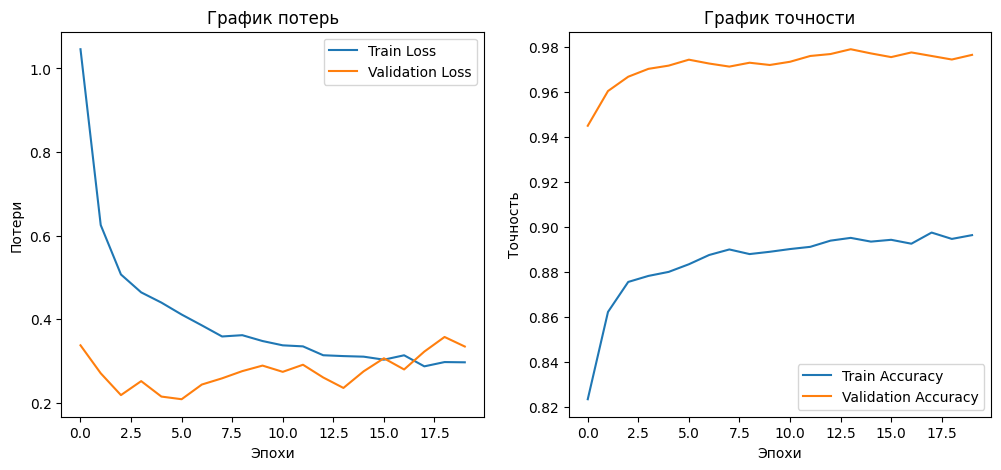

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

#MLP
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),  #преобразование изображения 28x28 в вектор
    tf.keras.layers.Dense(128, activation='relu'),  #полносвязный слой с 128 нейронами и ReLU
    tf.keras.layers.Dense(64, activation='relu'),   #полносвязный слой с 64 нейронами
    tf.keras.layers.Dense(10, activation='softmax'), #выходной слой (10 классов, softmax для вероятностей)
    tf.keras.layers.Dropout(0.1) 
])

#компиляция
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])



X_train = np.array(X_train).reshape(-1, 28, 28)
X_test = np.array(X_test).reshape(-1, 28, 28)

#обучение
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test), batch_size=32)



plt.figure(figsize=(12, 5))

#Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Эпохи')
plt.ylabel('Потери')
plt.title('График потерь')
plt.legend()

#Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Эпохи')
plt.ylabel('Точность')
plt.title('График точности')
plt.legend()

plt.show()


Train Accuracy = 90% → модель хорошо обучается, но не переобучается.
Validation Accuracy = 97.8% → почти максимум для MLP на MNIST.
Validation Loss остается стабильным, без сильных скачков → обобщение модели хорошее.

k-ближайших соседей (kNN)

Алгоритм: kNN (k = 3)

Принцип работы: при классификации нового объекта находит k ближайших точек в обучающей выборке и выбирает наиболее частый класс среди них.

k = 3 (3 ближайших соседа).

Метрика расстояния: Евклидово расстояние.

Достоинства: Прост в реализации и работает хорошо на небольших наборах данных.

Недостатки: Очень медленный на больших данных, так как требует вычисления расстояний до всех точек. Чувствителен к выбору k. Не учитывает пространственные зависимости (как в изображениях).

Многослойный перцептрон (MLP) архитектура:

Входной слой- 28×28 (784 пикселя, преобразованные в вектор), скрытые слои - 2 слоя с 128 и 64 нейронами, ReLU, Dropout(0.1) - защита от переобучения. Выходной слой - 10 классов (softmax), оптимизатор - Adam и функция потерь - Sparse Categorical Crossentropy. Эпохи -20

Достоинства: хорошо обобщает данные (не просто запоминает их). Быстрое предсказание после обучения и глубокая структура позволяет учитывать сложные зависимости.

Недостатки: требует больше вычислительных ресурсов при обучении и не так хорошо работает на небольших наборах данных (может переобучаться).

##  Сравнительный анализ и выводы

| Критерий | kNN | MLP |
|----------|----|----|
| **Точность** | 96% | **97.9%**  |
| **Скорость обучения** | **Быстрое**  | Долгое  |
| **Скорость предсказания** | **Очень медленное**  | **Быстрое**  |
| **Обобщающая способность** | **Плохая** (запоминает данные)  | **Хорошая**  |
| **Работа с изображениями** | **Плохо** (не учитывает пространственные паттерны)  | **Лучше** (но CNN еще лучше)  |

###  Вывод:
- **kNN** можно использовать **только на маленьких данных**, но он **медленный при предсказаниях**.
- **MLP работает лучше**, точность выше, предсказывает **быстро**.
- **MLP — лучший вариант для MNIST**
